# Algoritmo Genético y Mapa Autoorganizado (SOM)

## 1. Importación de Datos Transformados (PCA)

En este bloque cargamos el ecosistema geométrico que preparamos en el Script 3. Nuestro dataset ahora cuenta con las variables de identificación y 4 Componentes Principales (PC1 a PC4) que encapsulan el 87.3% de la información táctica de los jugadores, completamente estandarizada y libre de asimetrías extremas.

In [2]:
import pandas as pd
import numpy as np
from IPython.display import display

print("="*80)
print(" 📥 CARGA DE DATOS GEOMÉTRICOS (PCA)")
print("="*80)

# 1. Definir la ruta del archivo que exportamos en el Script 3
ruta_csv = '/content/drive/MyDrive/dataset_pca_som_1516.csv'

# 2. Cargar el DataFrame
df_som = pd.read_csv(ruta_csv)

# 3. Extraer solo la matriz matemática (las 4 dimensiones del PCA) para el entrenamiento
columnas_pca = ['PC1', 'PC2', 'PC3', 'PC4','PC5']
X_train = df_som[columnas_pca].values

print(f"✅ Dataset cargado con éxito. Total de jugadores: {df_som.shape[0]}")
print(f"✅ Matriz de entrenamiento 'X_train' lista: {X_train.shape[0]} filas x {X_train.shape[1]} dimensiones.")
print("-" * 80)
display(df_som.head())

 📥 CARGA DE DATOS GEOMÉTRICOS (PCA)
✅ Dataset cargado con éxito. Total de jugadores: 1699
✅ Matriz de entrenamiento 'X_train' lista: 1699 filas x 5 dimensiones.
--------------------------------------------------------------------------------


,player,team,competition_name,position_group,position_detail,minutos_jugados,xG P90,xG por Tiro,Asistencias a Tiro P90,% Centralidad Equipo,...,Tackles Ganados PAdj P90,Recup. Último Tercio P90,Conducciones Progresivas P90,Faltas Recibidas P90,Pérdidas de Balón P90,PC1,PC2,PC3,PC4,PC5
0,Aaron Cresswell,West Ham United,Premier League,Defensa,Left Back,3398,0.702436,-0.108761,1.911376,1.882894,...,1.489637,1.765272,1.502978,1.625387,1.527432,5.111888,-0.853621,0.077847,-0.914828,-0.290333
1,Aaron Lennon,Everton,Premier League,Mediocampista,Center Attacking Midfield,2130,-0.809785,-1.038399,0.201669,-0.737103,...,0.206758,-0.491908,-0.124415,0.183501,-0.024277,-1.026430,0.250574,0.218919,-1.506310,-0.163386
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista,Center Attacking Midfield,2826,-0.471666,-0.011930,0.966484,-0.385801,...,-0.931814,0.406766,-0.494812,-0.052754,-0.230979,-0.562633,0.498737,-0.818319,-0.757499,-1.264960
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista,Left Center Midfield,1902,-0.645998,-0.055713,1.168774,0.756284,...,0.364317,0.567213,0.364933,-0.267867,-0.306513,0.940424,-0.457903,-0.121828,-0.913221,-0.002754
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista,Center Attacking Midfield,1902,-0.168084,0.260612,1.731109,0.283537,...,0.870337,0.303838,0.221202,0.673524,0.586920,1.878574,0.285184,0.265322,-0.682697,-0.455789


## 2. Búsqueda de Hiperparámetros: Motor Evolutivo con Cataclismos

Para garantizar que el Mapa Autoorganizado (SOM) no se despliegue con hiperparámetros arbitrarios, utilizaremos un **Algoritmo Genético (AG)** diseñado para explorar el espacio de soluciones y encontrar la combinación perfecta de:
1.  **Dimensiones de la Grilla (X, Y):** El tamaño del mapa.
2.  **Tasa de Aprendizaje (LR):** Qué tan rápido aprenden las neuronas.
3.  **Radio de Vecindad ($\sigma$):** Cuántas neuronas vecinas se actualizan juntas.

### 🧬 Arquitectura del Algoritmo
*   **Función de Aptitud (Fitness):** Busca minimizar el Error de Cuantización (QE, 40%) y el Error Topológico (TE, 60%). Además, penaliza las grillas que se alejen demasiado de la heurística matemática ideal de $5\sqrt{N}$.
*   **Elitismo Blindado:** El espécimen con mejor *fitness* de cada generación sobrevive intacto a la siguiente, evitando regresiones en el aprendizaje.
*   **Mutación Híbrida:** Los genes tienen un 50% de probabilidad de sufrir una *Micro-mutación* (un ajuste fino mediante ruido gaussiano) o una *Macro-mutación* (un salto ciego en el espacio de búsqueda para explorar nuevos territorios).
*   **Sistema de Cataclismos:** Si el algoritmo detecta un estancamiento evolutivo durante 3 generaciones consecutivas (mínimo local), activa un "Cataclismo" que purga al 50% de la población más débil, reemplazándola con individuos aleatorios completamente nuevos para forzar la diversidad genética.

In [3]:
import random
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias matemáticas menores durante la evolución

# ==================================================================================
# 1. LIMITES Y CONFIGURACION HEURÍSTICA
# ==================================================================================
datos_entrenamiento = X_train

# Heurística: 5 * sqrt(N). Para ~1700 jugadores, el target es ~206 neuronas.
neuronas_target = int(5 * np.sqrt(len(datos_entrenamiento)))
margen = 0.3
limite_inferior = int(neuronas_target * (1 - margen))
limite_superior = int(neuronas_target * (1 + margen))

# Límites de los genes: [X_dim, Y_dim, Sigma, LR]
BOUNDS = [(5, 20), (5, 20), (1.0, 10.0), (0.05, 0.9)]

def crear_individuo():
    return [
        random.randint(BOUNDS[0][0], BOUNDS[0][1]),
        random.randint(BOUNDS[1][0], BOUNDS[1][1]),
        random.uniform(BOUNDS[2][0], BOUNDS[2][1]),
        random.uniform(BOUNDS[3][0], BOUNDS[3][1])
    ]

# ==================================================================================
# 2. FUNCIONES DE EVALUACIÓN (SOM RÁPIDO Y ERRORES)
# ==================================================================================
def topological_error(weights, data):
    """Calcula el TE verificando si los 2 BMUs de cada dato son adyacentes en la grilla."""
    n_features = weights.shape[2]
    dists = np.sqrt(np.sum((weights.reshape(-1, n_features) - data[:, np.newaxis, :])**2, axis=2))
    bmu_indices = np.argsort(dists, axis=1)[:, :2]

    m, n = weights.shape[0], weights.shape[1]
    bmu1 = np.unravel_index(bmu_indices[:, 0], (m, n))
    bmu2 = np.unravel_index(bmu_indices[:, 1], (m, n))

    grid_dist = np.abs(bmu1[0] - bmu2[0]) + np.abs(bmu1[1] - bmu2[1])
    return np.mean(grid_dist > 1)

def train_som_fast(data, m, n, n_iter, alpha0, sigma0):
    """Entrenamiento ligero del SOM para la evaluación genética."""
    n_features = data.shape[1]

    # FIX VITAL: Inicializar los pesos dentro del rango real de los datos del PCA
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    weights = np.random.uniform(min_vals, max_vals, (m, n, n_features))

    grid_pos = np.array([[(i, j) for j in range(n)] for i in range(m)], dtype=float)
    lam = n_iter / np.log(sigma0 + 1e-8)

    for t in range(n_iter):
        x = data[np.random.randint(len(data))]
        dists_to_x = np.sum((weights - x)**2, axis=2)
        bmu_idx = np.unravel_index(np.argmin(dists_to_x), (m, n))

        a_t = alpha0 * np.exp(-t / lam)
        s_t = sigma0 * np.exp(-t / lam)

        dist_grid_sq = np.sum((grid_pos - np.array(bmu_idx))**2, axis=2)
        h = np.exp(-dist_grid_sq / (2.0 * s_t**2 + 1e-8))
        weights += a_t * h[:, :, np.newaxis] * (x - weights)

    # Cálculo final del Error de Cuantización (QE)
    qe = np.mean([np.min(np.sum((weights - d)**2, axis=2)) for d in data])
    return weights, qe

def calcular_fitness_avanzado(cromosoma, datos):
    x_dim, y_dim, sigma, lr = cromosoma
    total_neuronas = x_dim * y_dim

    # Penalización si nos alejamos de la heurística matemática
    penalizacion = 0
    if total_neuronas < limite_inferior or total_neuronas > limite_superior:
        desviacion = min(abs(total_neuronas - limite_inferior), abs(total_neuronas - limite_superior))
        penalizacion = desviacion * 0.05

    try:
        # Entrenamos un mini-SOM de 3000 iteraciones para evaluar el cromosoma
        pesos_temp, qe_real = train_som_fast(datos, int(x_dim), int(y_dim), 3000, lr, sigma)
        te_real = topological_error(pesos_temp, datos)

        # FITNESS: Buscamos minimizar esta función
        fitness = (qe_real * 0.4) + (te_real * 0.6) + penalizacion
        return fitness
    except:
        return float('inf')

# ==================================================================================
# 3. MOTOR EVOLUTIVO (BÚSQUEDA BRUSCA Y CATACLISMOS)
# ==================================================================================
TAMAÑO_POBLACION = 30
GENERACIONES = 100
PROB_CRUCE = 0.85
PROB_MUTACION = 0.40 # Alta probabilidad para fomentar exploración

poblacion = [crear_individuo() for _ in range(TAMAÑO_POBLACION)]
mejor_fitness_global = float('inf')
mejor_historico_gen = None

estancamiento = 0 # Contador para activar el cataclismo

print("="*80)
print(f" 🧬 INICIANDO AG DE EXPLORACIÓN PROFUNDA | Target: ~{neuronas_target} neuronas")
print("="*80)

for gen in range(GENERACIONES):
    fitness_poblacion = [calcular_fitness_avanzado(ind, datos_entrenamiento) for ind in poblacion]

    # Ordenar población de menor a mayor fitness (menor es mejor)
    poblacion_ordenada = [x for _, x in sorted(zip(fitness_poblacion, poblacion), key=lambda pair: pair[0])]
    fitness_ordenado = sorted(fitness_poblacion)

    # Evaluación de estancamiento
    if fitness_ordenado[0] < mejor_fitness_global:
        mejor_fitness_global = fitness_ordenado[0]
        mejor_historico_gen = poblacion_ordenada[0].copy()
        estancamiento = 0 # Reseteamos si hay mejora
    else:
        estancamiento += 1 # Aumenta si nos quedamos pegados

    print(f"Gen {gen+1:02d} | Fitness: {mejor_fitness_global:.4f} | Malla: {int(poblacion_ordenada[0][0])}x{int(poblacion_ordenada[0][1])} | S: {poblacion_ordenada[0][2]:.2f} | LR: {poblacion_ordenada[0][3]:.2f}")

    nueva_poblacion = []

    # 1. ELITISMO BLINDADO: El mejor siempre vive intacto
    nueva_poblacion.append(poblacion_ordenada[0].copy())

    # 2. CONTROL DE CATACLISMO: Si se estanca 3 veces seguidas, arrasamos con la mitad de la población
    if estancamiento >= 3 and gen < GENERACIONES - 1:
        print(f"    ⚠️ ESTANCAMIENTO DETECTADO. Iniciando Cataclismo (50% purgado).")
        num_aliens = int(TAMAÑO_POBLACION * 0.50)
        for _ in range(num_aliens):
            nueva_poblacion.append(crear_individuo())
        estancamiento = 0 # Damos tiempo a la nueva población para converger

    # 3. SELECCIÓN, CRUCE Y MUTACIÓN
    while len(nueva_poblacion) < TAMAÑO_POBLACION:
        # Selección por Torneo (agarran 2 al azar y gana el mejor)
        i1, i2 = random.sample(range(TAMAÑO_POBLACION), 2)
        ganador = poblacion[i1] if fitness_poblacion[i1] < fitness_poblacion[i2] else poblacion[i2]

        hijo = ganador.copy()

        # Cruce contra otro aleatorio
        if random.random() < PROB_CRUCE:
            pareja = random.choice(poblacion)
            for gen_idx in range(4):
                if random.random() < 0.5:
                    hijo[gen_idx] = pareja[gen_idx]

        # Mutación Brusca (Macro vs Micro)
        if random.random() < PROB_MUTACION:
            gen_m = random.randint(0, 3)

            # Lanzamos moneda: 50% Macro-mutación / 50% Micro-mutación
            if random.random() < 0.5:
                # MACRO: Salto ciego
                if gen_m < 2:
                    hijo[gen_m] = random.randint(BOUNDS[gen_m][0], BOUNDS[gen_m][1])
                else:
                    hijo[gen_m] = random.uniform(BOUNDS[gen_m][0], BOUNDS[gen_m][1])
            else:
                # MICRO: Ajuste Gaussiano fino
                if gen_m < 2:
                    cambio = random.choice([-1, 1])
                    hijo[gen_m] = max(BOUNDS[gen_m][0], min(BOUNDS[gen_m][1], hijo[gen_m] + cambio))
                else:
                    sigma_ruido = 1.0 if gen_m == 2 else 0.05
                    nuevo_valor = hijo[gen_m] + random.gauss(mu=0, sigma=sigma_ruido)
                    hijo[gen_m] = max(BOUNDS[gen_m][0], min(BOUNDS[gen_m][1], nuevo_valor))

        nueva_poblacion.append(hijo)

    # Nos aseguramos de no pasarnos del límite de la población
    poblacion = nueva_poblacion[:TAMAÑO_POBLACION]

# ==================================================================================
# 4. RESULTADOS FINALES
# ==================================================================================
x_opt, y_opt, sigma_opt, lr_opt = mejor_historico_gen
print("\n" + "="*80)
print(f" 🏆 BÚSQUEDA FINALIZADA. MEJORES HIPERPARÁMETROS CAPTURADOS:")
print("="*80)
print(f"🔸 Grilla SOM : {int(x_opt)}x{int(y_opt)} (Total: {int(x_opt)*int(y_opt)} neuronas)")
print(f"🔸 Sigma (σ)  : {sigma_opt:.2f}")
print(f"🔸 Learn. Rate: {lr_opt:.3f}")
print(f"🔸 Fitness    : {mejor_fitness_global:.4f}")
print("="*80)

 🧬 INICIANDO AG DE EXPLORACIÓN PROFUNDA | Target: ~206 neuronas
Gen 01 | Fitness: 0.3636 | Malla: 12x20 | S: 4.39 | LR: 0.60
Gen 02 | Fitness: 0.3636 | Malla: 19x11 | S: 6.42 | LR: 0.52
Gen 03 | Fitness: 0.3337 | Malla: 14x19 | S: 7.39 | LR: 0.88
Gen 04 | Fitness: 0.3256 | Malla: 14x19 | S: 7.39 | LR: 0.88
Gen 05 | Fitness: 0.3256 | Malla: 14x19 | S: 7.39 | LR: 0.88
Gen 06 | Fitness: 0.3256 | Malla: 14x19 | S: 7.39 | LR: 0.88
Gen 07 | Fitness: 0.3256 | Malla: 13x18 | S: 6.81 | LR: 0.88
    ⚠️ ESTANCAMIENTO DETECTADO. Iniciando Cataclismo (50% purgado).
Gen 08 | Fitness: 0.3256 | Malla: 12x20 | S: 7.39 | LR: 0.83
Gen 09 | Fitness: 0.3256 | Malla: 12x20 | S: 7.39 | LR: 0.83
Gen 10 | Fitness: 0.3256 | Malla: 15x17 | S: 4.75 | LR: 0.52
    ⚠️ ESTANCAMIENTO DETECTADO. Iniciando Cataclismo (50% purgado).
Gen 11 | Fitness: 0.3256 | Malla: 14x14 | S: 3.14 | LR: 0.25
Gen 12 | Fitness: 0.3256 | Malla: 14x14 | S: 3.14 | LR: 0.25
Gen 13 | Fitness: 0.3256 | Malla: 13x19 | S: 2.12 | LR: 0.31
    ⚠️ 

## 3. Entrenamiento Definitivo del Mapa Autoorganizado (SOM)

Con los hiperparámetros óptimos capturados por el Algoritmo Genético, procedemos a ejecutar el entrenamiento masivo del modelo SOM (100,000 iteraciones).

Este paso "asienta" la red neuronal. Evaluaremos su calidad final observando dos métricas clave:
1. **Error de Cuantización (QE):** Mide la resolución del mapa. Responde a "¿Qué tan parecidos son realmente los jugadores agrupados en una misma neurona?".
2. **Error Topológico (TE):** Mide la suavidad de la transición táctica. Responde a "¿La estructura táctica del fútbol se conservó de manera continua o el mapa está 'roto'?".

In [4]:
# ==================================================================================
# BLOQUE 4: ENTRENAMIENTO DEFINITIVO SOM [MODELO OPTIMIZADO POR AG]
# ==================================================================================

# 1. Recuperamos los mejores parámetros del histórico del AG
x_opt, y_opt, sigma_opt, lr_opt = mejor_historico_gen

M_ag = int(x_opt)
N_ag = int(y_opt)
sigma0_ag = sigma_opt
alpha0_ag = lr_opt
n_iter_final = 100000 # Entrenamiento masivo para asentar las neuronas

print("="*80)
print(" 🧠 INICIANDO ENTRENAMIENTO PROFUNDO SOM [MODELO OPTIMIZADO]")
print("="*80)
print(f"🔸 Arquitectura : Grilla {M_ag}x{N_ag} ({M_ag * N_ag} neuronas)")
print(f"🔸 Parámetros   : Sigma = {sigma0_ag:.2f} | LR = {alpha0_ag:.4f}")
print(f"🔸 Iteraciones  : {n_iter_final}")
print("-" * 80)
print("Entrenando... (Esto puede tomar unos minutos dependiendo de tu CPU)")

# 2. Ejecución del entrenamiento con los datos geométricos del PCA
pesos_ag, qe_ag = train_som_fast(
    X_train, M_ag, N_ag, n_iter_final, alpha0_ag, sigma0_ag
)

# 3. Cálculo del Error Topológico (TE) final y Fitness
te_ag = topological_error(pesos_ag, X_train)

# Re-calculamos la penalización por si la grilla óptima se alejó del ideal matemático
total_neuronas = M_ag * N_ag
penalizacion = 0
if total_neuronas < limite_inferior or total_neuronas > limite_superior:
    desviacion = min(abs(total_neuronas - limite_inferior), abs(total_neuronas - limite_superior))
    penalizacion = desviacion * 0.05

# Fitness final con los pesos ya hiper-ajustados (100k iteraciones)
fitness_final = (qe_ag * 0.4) + (te_ag * 0.6) + penalizacion

# 4. Resumen de Salida
print("\n" + "="*80)
print(" 🏆 ENTRENAMIENTO DEFINITIVO COMPLETADO 🏆")
print("="*80)
print(f"✅ Error de Cuantización (QE) : {qe_ag:.4f}  (Precisión de agrupación)")
print(f"✅ Error Topológico (TE)      : {te_ag:.4f}  (Continuidad del mapa)")
if penalizacion > 0:
    print(f"⚠️ Penalización por tamaño    : {penalizacion:.4f}")
print("-" * 80)
print(f"🎯 FITNESS FINAL COMBINADO    : {fitness_final:.4f}")
print("="*80)

 🧠 INICIANDO ENTRENAMIENTO PROFUNDO SOM [MODELO OPTIMIZADO]
🔸 Arquitectura : Grilla 15x17 (255 neuronas)
🔸 Parámetros   : Sigma = 4.86 | LR = 0.6170
🔸 Iteraciones  : 100000
--------------------------------------------------------------------------------
Entrenando... (Esto puede tomar unos minutos dependiendo de tu CPU)

 🏆 ENTRENAMIENTO DEFINITIVO COMPLETADO 🏆
✅ Error de Cuantización (QE) : 0.5757  (Precisión de agrupación)
✅ Error Topológico (TE)      : 0.1418  (Continuidad del mapa)
--------------------------------------------------------------------------------
🎯 FITNESS FINAL COMBINADO    : 0.3154


## 4. Búsqueda del K-Óptimo (Macro-Clústeres)

El SOM ha creado cientos de neuronas con micro-perfiles. Para que este mapa sea interpretable y útil para el scouting, debemos agrupar estas neuronas en **Macro-Arquetipos Tácticos** (por ejemplo: "Organizadores", "Destructores", "Finalizadores").

Para determinar el número ideal de grupos, aplicamos el algoritmo de K-Means sobre los pesos de la red y evaluamos dos métricas matemáticas:
1. **Método del Codo (Inercia):** Busca el punto donde añadir más clústeres deja de reducir significativamente la varianza interna.
2. **Silhouette Score:** Mide qué tan bien separado está cada clúster de los demás. Buscamos el punto más alto en esta curva.

 📊 EVALUANDO NÚMERO ÓPTIMO DE MACRO-CLÚSTERES TÁCTICOS


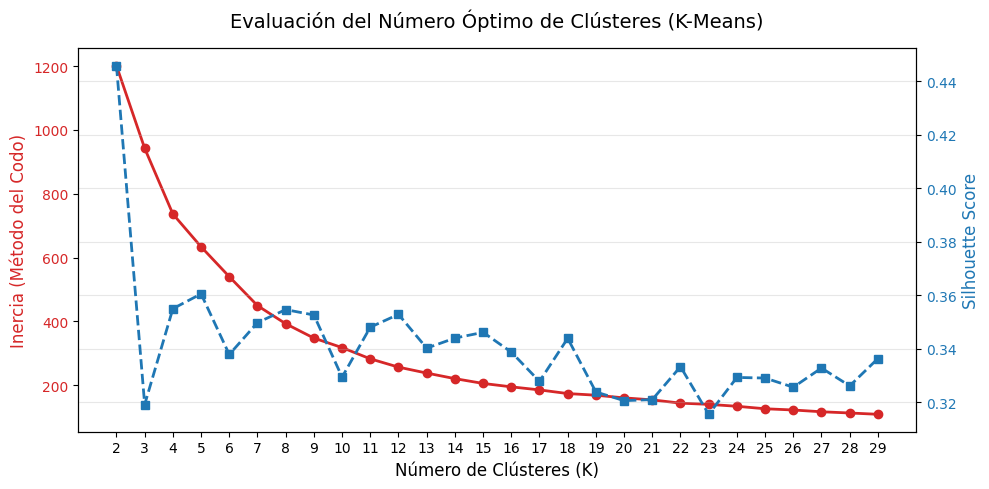

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("="*80)
print(" 📊 EVALUANDO NÚMERO ÓPTIMO DE MACRO-CLÚSTERES TÁCTICOS")
print("="*80)

# 1. Extraemos las dimensiones del modelo optimizado
M, N, n_features = pesos_ag.shape

# 2. Aplanamos la matriz de pesos 3D a 2D (Neuronas x Variables)
pesos_aplanados = pesos_ag.reshape(M * N, n_features)

inercia = []
silueta = []
rango_k = range(2, 30) # Probamos entre 2 y 20 clústeres macro

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(pesos_aplanados)
    inercia.append(kmeans.inertia_)
    silueta.append(silhouette_score(pesos_aplanados, etiquetas))

# 3. VISUALIZACIÓN DE LAS MÉTRICAS
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Número de Clústeres (K)', fontsize=12)
ax1.set_ylabel('Inercia (Método del Codo)', color=color, fontsize=12)
ax1.plot(rango_k, inercia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(rango_k, silueta, marker='s', color=color, linewidth=2, linestyle='dashed')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluación del Número Óptimo de Clústeres (K-Means)', fontsize=14, pad=15)
plt.xticks(rango_k)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Clustering Definitivo y Exportación de Datos

En esta fase final del entrenamiento, extraemos los clústeres matemáticos generados por el SOM para preparar la base de datos de cara al análisis táctico.

1. **Agrupación de Neuronas:** Aplicamos K-Means sobre los pesos de la red neuronal para formar los Macro-Arquetipos (cuyo número óptimo definimos en el paso anterior).
2. **Asignación de Jugadores:** Calculamos la neurona ganadora (BMU) para cada jugador en el espacio topológico y le asignamos su Macro-Arquetipo correspondiente.
3. **Consolidación y Exportación:** Integramos estas etiquetas con nuestra base de datos original (que ya contiene las métricas tácticas transformadas) y exportamos el archivo a Google Drive. Este dataset será el motor de nuestro próximo script de *Scouting* e Interpretación.

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 🚨 CAMBIA ESTE NÚMERO (K_OPTIMO) por el que elijas tras ver el gráfico de Codo/Silueta
K_OPTIMO = 7

print("="*85)
print(f" 🧬 GENERANDO {K_OPTIMO} MACRO-CLÚSTERES Y EXPORTANDO DATASET")
print("="*85)

# 1. AGRUPACIÓN DE LAS NEURONAS (K-Means)
# Usamos 'pesos_aplanados' y 'pesos_ag' calculados en el bloque anterior
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20)
etiquetas_neuronas = kmeans_final.fit_predict(pesos_aplanados)
cluster_mapa = etiquetas_neuronas.reshape(M, N)

# 2. ASIGNAMOS CADA JUGADOR A SU CLÚSTER CORRESPONDIENTE
etiquetas_jugadores = []
for jugador in X_train:
    # Calculamos el BMU midiendo distancias matemáticas
    dists = np.sum((pesos_ag - jugador)**2, axis=2)
    bmu = np.unravel_index(np.argmin(dists), (M, N))
    etiquetas_jugadores.append(cluster_mapa[bmu[0], bmu[1]])

# 3. CONSOLIDACIÓN DE LA BASE DE DATOS
# 'df_som' ya contiene nombres, info y las 14 métricas reales que arreglamos antes
df_resultados = df_som.copy()
df_resultados['Arquetipo_SOM'] = etiquetas_jugadores

# 4. EXPORTACIÓN AUTOMÁTICA A GOOGLE DRIVE
ruta_exportacion = '/content/drive/MyDrive/dataset_final_clusters.csv'
df_resultados.to_csv(ruta_exportacion, index=False)

print(f"✅ ¡Clustering finalizado exitosamente!")
print(f"✅ Se han asignado los {K_OPTIMO} Arquetipos Tácticos a los {len(df_resultados)} jugadores.")
print(f"✅ Dataset guardado y actualizado en: {ruta_exportacion}")
print("\n➡️ SCRIPT 4 COMPLETADO. Ve al Script 5 para iniciar el Análisis Táctico.")
print("="*85)

 🧬 GENERANDO 7 MACRO-CLÚSTERES Y EXPORTANDO DATASET
✅ ¡Clustering finalizado exitosamente!
✅ Se han asignado los 7 Arquetipos Tácticos a los 1699 jugadores.
✅ Dataset guardado y actualizado en: /content/drive/MyDrive/dataset_final_clusters.csv

➡️ SCRIPT 4 COMPLETADO. Ve al Script 5 para iniciar el Análisis Táctico.
